In [1]:
import kairo
import warnings
warnings.filterwarnings("ignore")
from dotenv import load_dotenv
from pathlib import Path
import os
import base64
import plotly.graph_objects as go
from IPython.display import Image, display

load_dotenv(Path("../..") / ".env")

True

In [2]:
log = kairo.read_log("../../data/test.xes",
    case_id = "case:concept:id",
    activity = "concept:activity",
    timestamp = "time:completed",
    event_id = "event:uidd",
    start_timestamp = "begin:timestamp",
    resource = "org:actor",
    event_duration = "event:runtime_min")
log.head()

parsing log, completed traces :: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 2504.06it/s]


,event:id,concept:name,start_timestamp,time:timestamp,event:duration_min,org:resource,case:concept:name,case:amount,case:region
0,e001,Create Order,2026-03-02 08:00:00+00:00,2026-03-02 08:12:00+00:00,12,Anna,C001,1200.5,EU
1,e002,Check Credit,2026-03-02 08:30:00+00:00,2026-03-02 08:50:00+00:00,20,Ben,C001,1200.5,EU
2,e003,Approve Order,2026-03-02 09:15:00+00:00,2026-03-02 09:25:00+00:00,10,Clara,C001,1200.5,EU
3,e004,Ship Goods,2026-03-03 10:00:00+00:00,2026-03-03 10:45:00+00:00,45,Dmitri,C001,1200.5,EU
4,e005,Create Order,2026-03-02 09:05:00+00:00,2026-03-02 09:20:00+00:00,15,Anna,C002,350.0,NA


In [19]:
stats = kairo.compute_log_stats(log)
stats

{'cases': 3,
 'events': 12,
 'activities': 6,
 'resources': 5,
 'start': Timestamp('2026-03-02 08:12:00+0000', tz='UTC'),
 'end': Timestamp('2026-03-05 09:20:00+0000', tz='UTC'),
 'span_minutes': 4388.0,
 'tpt_days_min': 0.08194444444444444,
 'tpt_days_mean': 1.0800925925925926,
 'tpt_days_median': 1.10625,
 'tpt_days_max': 2.0520833333333335,
 'length_min': 3,
 'length_mean': 4.0,
 'length_median': 4.0,
 'length_max': 5,
 'activity_counts': concept:name
 Create Order     3
 Check Credit     3
 Approve Order    2
 Ship Goods       2
 Reject Order     1
 Send Invoice     1
 Name: count, dtype: int64,
 'resource_counts': org:resource
 Anna      3
 Ben       3
 Clara     3
 Dmitri    2
 Emre      1
 Name: count, dtype: int64}

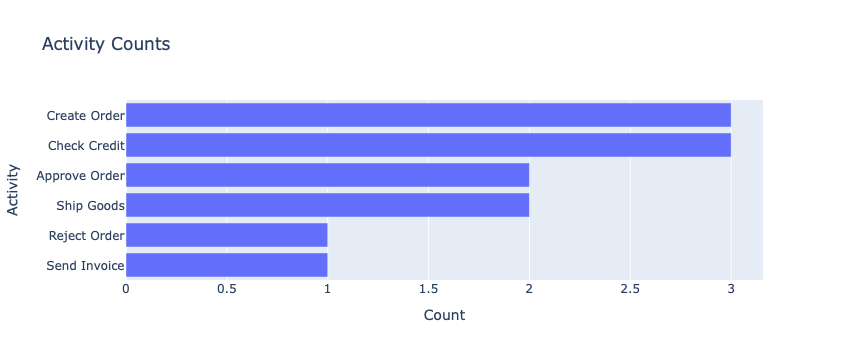

In [20]:
activity_plot = kairo.plot_activity_counts(stats)
activity_plot.show()

In [22]:
llm = kairo.LLMConnector(
    provider="anthropic",
    api_key=os.environ["ANTHROPIC_API_KEY"],
    model="claude-haiku-4-5-20251001"
)

response = llm.call(
    prompt="Very briefly analyze this process mining activity distribution. Do not use markdown format, just raw text",
    plots=[activity_plot],
)

response

Message(id='msg_011CfHAfry8F1twxswVtRPS1', container=None, content=[TextBlock(citations=None, text='The activity distribution shows a typical order-to-cash process with clear volume patterns. Create Order and Check Credit are the most frequent activities, each occurring approximately 3,000 times, indicating these are mandatory steps for all transactions. Approve Order and Ship Goods follow with roughly 2,000 occurrences each, representing the core fulfillment path. Reject Order and Send Invoice are the least frequent at around 1,000 each, with rejections being a small subset of orders and invoicing occurring post-shipment. The distribution suggests a healthy process where most orders progress through approval and shipping stages, with a reasonable rejection rate and consistent invoicing. The concentration of activities in the first three steps indicates potential bottleneck areas for optimization.', type='text')], model='claude-haiku-4-5-20251001', role='assistant', stop_details=None, 

In [11]:
features = kairo.compute_features_intra(log, ["past_acts"], sliding_window_size=1)
features

,past_act_1:Approve Order,past_act_1:Check Credit,past_act_1:Create Order,past_act_1:Reject Order,past_act_1:Send Invoice,past_act_1:Ship Goods
0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0
5,0.0,0.0,1.0,0.0,0.0,0.0
6,0.0,1.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,1.0,0.0,0.0,0.0
9,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0
